In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import importlib
import auxiliares

from pathlib import Path
from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import InputPair, Config

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Calibracion estereo y computo de mapas de rectificacion

In [2]:
# Directorio base de los resultados de calibración
base_dir = "imgs/calibracion"

# Ruta al archivo existente de calibración estéreo
calib_file = os.path.join(base_dir, "stereo_calibration.pkl")

# Cargar la calibración
with open(calib_file, "rb") as f:
    calib = pickle.load(f)

# Imprimir los parámetros de calibración
def np_print(name, arr):
    np.set_printoptions(precision=4, suppress=True)
    print(f"\n{name} =\n{arr}")

print("### PARÁMETROS DE CALIBRACIÓN ESTÉREO ###")
np_print("Matriz intrínseca cámara izquierda (K1)", calib["left_K"])
np_print("Coef. distorsión izquierda (d1)", calib["left_dist"])
np_print("Matriz intrínseca cámara derecha (K2)", calib["right_K"])
np_print("Coef. distorsión derecha (d2)", calib["right_dist"])
np_print("Rotación (R)", calib["R"])
np_print("Traslación (T)", calib["T"])
np_print("Matriz esencial (E)", calib["E"])
np_print("Matriz fundamental (F)", calib["F"])

### PARÁMETROS DE CALIBRACIÓN ESTÉREO ###

Matriz intrínseca cámara izquierda (K1) =
[[596.3832   0.     950.5001]
 [  0.     596.4378 515.5356]
 [  0.       0.       1.    ]]

Coef. distorsión izquierda (d1) =
[[ 0.0211 -0.0344 -0.0066 -0.0004  0.0058]]

Matriz intrínseca cámara derecha (K2) =
[[595.3381   0.     944.1087]
 [  0.     595.7354 513.5429]
 [  0.       0.       1.    ]]

Coef. distorsión derecha (d2) =
[[ 0.0145 -0.0287 -0.0061 -0.0014  0.0042]]

Rotación (R) =
[[ 1.      0.0019  0.0069]
 [-0.0019  1.     -0.0002]
 [-0.0069  0.0001  1.    ]]

Traslación (T) =
[[-58.9755]
 [ -0.0693]
 [ -1.1424]]

Matriz esencial (E) =
[[ -0.0017   1.1424  -0.0695]
 [ -1.5471   0.0061  58.9663]
 [  0.18   -58.9752   0.0094]]

Matriz fundamental (F) =
[[ 0.     -0.      0.003 ]
 [ 0.     -0.     -0.1773]
 [-0.0044  0.1752  1.    ]]


In [3]:
# Extraer los parámetros necesarios
left_K = calib["left_K"]
left_dist = calib["left_dist"]
right_K = calib["right_K"]
right_dist = calib["right_dist"]
R = calib["R"]
T = calib["T"]

# Si pickle no tiene 'image_size', lo inferimos leyendo una imagen del dataset
if "image_size" in calib:
    image_size = calib["image_size"]
else:
    sample_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*left*.jpg"))[0]))
    image_size = (sample_img.shape[1], sample_img.shape[0])  # (w, h)
    print("⚠️ 'image_size' no estaba en el pickle, se infirió como:", image_size)

# Calcular la rectificación estéreo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist,
    right_K, right_dist,
    image_size,
    R, T,
    alpha=0
)

# Generar los mapas de rectificación
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1
)

# Guardar los mapas en un nuevo pickle
stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
}

maps_file = os.path.join(base_dir, "stereo_maps.pkl")
with open(maps_file, "wb") as f:
    pickle.dump(stereo_maps, f)

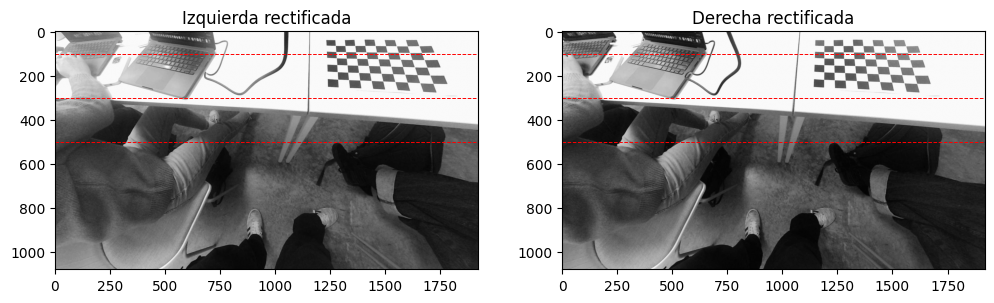

In [4]:
# Mostrar ejemplo de par de imagenes des-distorsionadas y rectificadas

# Cargar los mapas de rectificación
with open("imgs/calibracion/stereo_maps.pkl", "rb") as f:
    maps = pickle.load(f)

left_map_x, left_map_y = maps["left_map_x"], maps["left_map_y"]
right_map_x, right_map_y = maps["right_map_x"], maps["right_map_y"]

# Tomar un par de imágenes de calibración
left_img_path = sorted(glob.glob("imgs/calibracion/*left*.jpg"))[0]
right_img_path = sorted(glob.glob("imgs/calibracion/*right*.jpg"))[0]

imgL = cv2.imread(left_img_path, cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread(right_img_path, cv2.IMREAD_GRAYSCALE)

# Aplicar rectificación
rectL = cv2.remap(imgL, left_map_x, left_map_y, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, right_map_x, right_map_y, cv2.INTER_LINEAR)

# Mostrar
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(rectL, cmap="gray")
axes[0].set_title("Izquierda rectificada")
axes[1].imshow(rectR, cmap="gray")
axes[1].set_title("Derecha rectificada")

for y in [100, 300, 500]:
    axes[0].axhline(y, color='r', linestyle='--', linewidth=0.7)
    axes[1].axhline(y, color='r', linestyle='--', linewidth=0.7)

plt.show()

# Rectificación

In [5]:
importlib.reload(auxiliares)

auxiliares.rectificar_imagenes("imgs/objeto", "imgs/calibracion/stereo_maps.pkl")

🔹 Rectificando 21 pares de imágenes...
   ROI común aplicado: (x=0, y=0, w=1920, h=1079)
✅ Imágenes rectificadas guardadas en: imgs/objeto\rectificadas


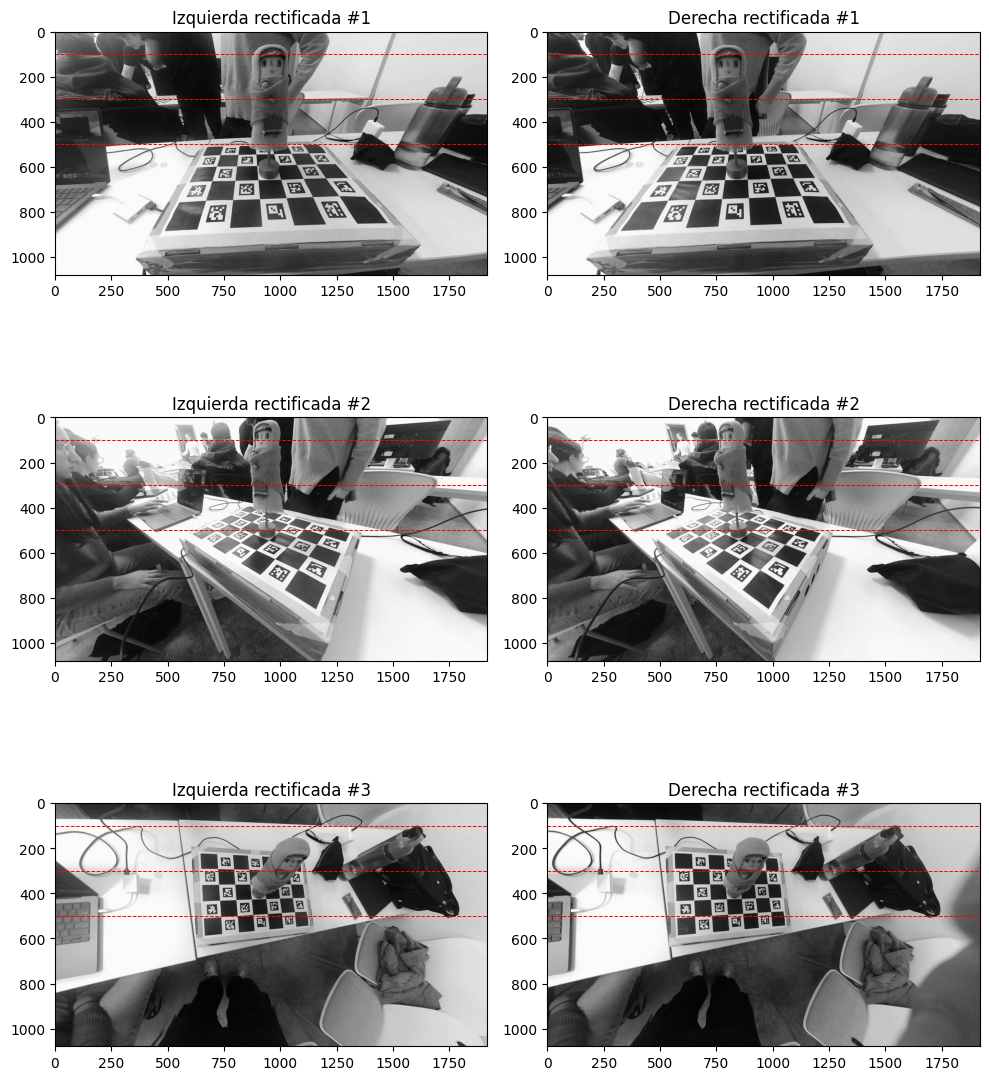

In [6]:
# Mostrar varios pares de imágenes rectificadas con líneas epipolares
left_imgs = sorted(glob.glob("imgs/objeto/rectificadas/rect_left_*.jpg"))
right_imgs = sorted(glob.glob("imgs/objeto/rectificadas/rect_right_*.jpg"))

n_ejemplos = 3  
fig, axes = plt.subplots(n_ejemplos, 2, figsize=(10, 4 * n_ejemplos))

for i in range(n_ejemplos):
    imgL = cv2.imread(left_imgs[i], cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_imgs[i], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(imgL, cmap="gray")
    axes[i, 0].set_title(f"Izquierda rectificada #{i+1}")
    axes[i, 1].imshow(imgR, cmap="gray")
    axes[i, 1].set_title(f"Derecha rectificada #{i+1}")

    for y in [100, 300, 500]:
        axes[i, 0].axhline(y, color='r', linestyle='--', linewidth=0.7)
        axes[i, 1].axhline(y, color='r', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()


# Disparidad

### Mapa de Disparidad



### BM

In [7]:
# Seleccionar los mismos tres pares de imágenes rectificadas
pares_indices = [0, 1, 2]  
pares_imgs = [(left_imgs[i], right_imgs[i]) for i in pares_indices]

# Guardar la selección para usar en ambos métodos
print("Pares seleccionados:")
for idx, (l, r) in zip(pares_indices, pares_imgs):
    print(f"  Par {idx+1}:")
    print(f"    Left → {os.path.basename(l)}")
    print(f"    Right → {os.path.basename(r)}")


Pares seleccionados:
  Par 1:
    Left → rect_left_0.jpg
    Right → rect_right_0.jpg
  Par 2:
    Left → rect_left_1.jpg
    Right → rect_right_1.jpg
  Par 3:
    Left → rect_left_10.jpg
    Right → rect_right_10.jpg


BM – Par 1 → min: -16.0, max: 3056.0


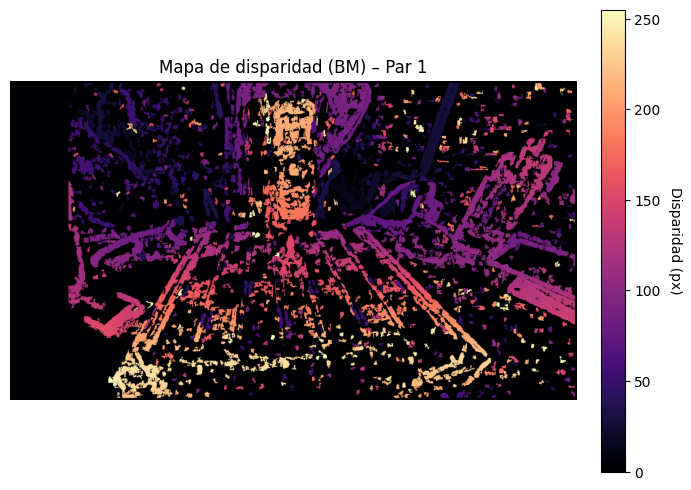

BM – Par 2 → min: -16.0, max: 3056.0


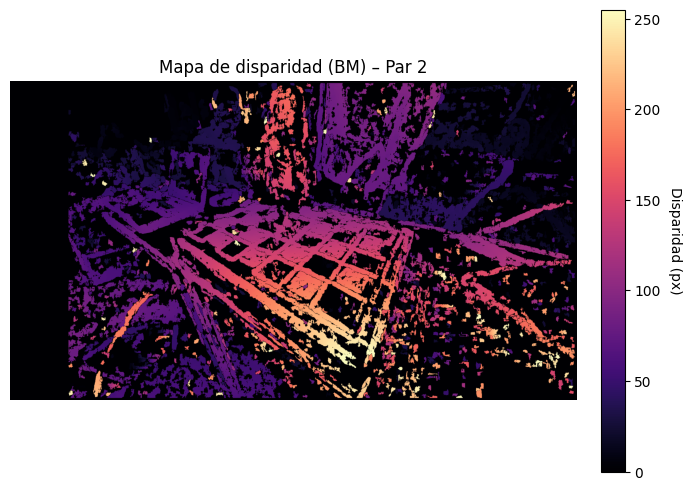

BM – Par 3 → min: -16.0, max: 3056.0


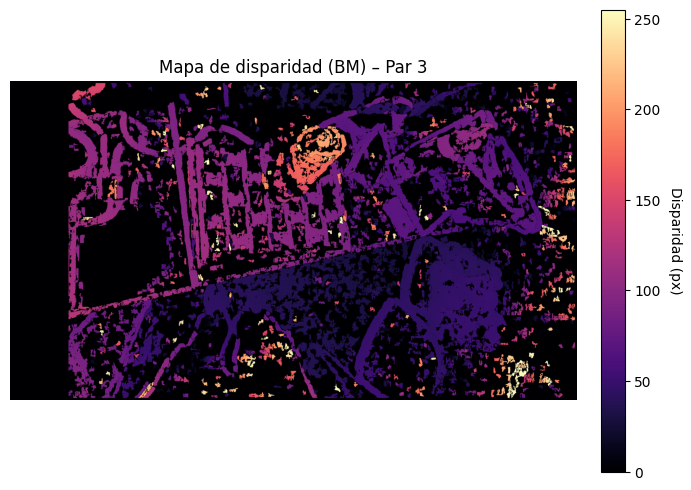

In [8]:
importlib.reload(auxiliares)

for idx, (left_path, right_path) in zip(pares_indices, pares_imgs):
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(
        imgL, imgR,
        build_matcher_fn=auxiliares.make_bm,
        num_disp=16*12,
        block=15,
        textureThreshold=10,
        uniquenessRatio=5,
        speckleRange=32,
        speckleWindowSize=100
    )

    print(f"BM – Par {idx+1} → min: {disp_raw.min():.1f}, max: {disp_raw.max():.1f}")

    plt.figure(figsize=(8,6))
    im = plt.imshow(disp_vis, cmap="magma")
    plt.title(f"Mapa de disparidad (BM) – Par {idx+1}")
    plt.axis("off")
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Disparidad (px)", rotation=270, labelpad=15)
    plt.show()

### SGBM

SGBM – Par 1 → min: -16.0, max: 3056.0


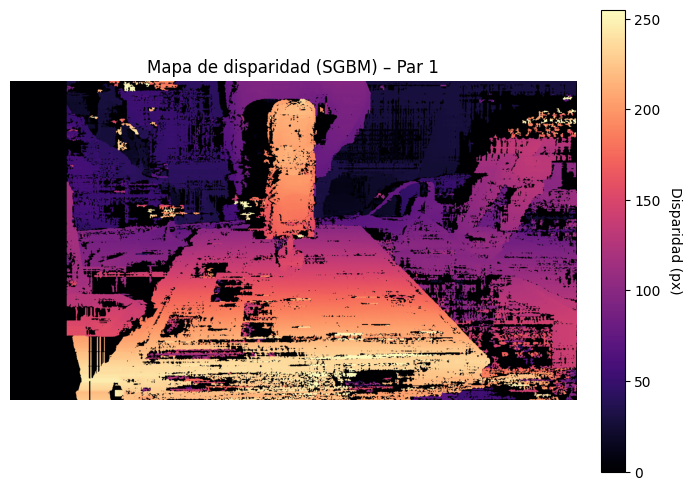

SGBM – Par 2 → min: -16.0, max: 3056.0


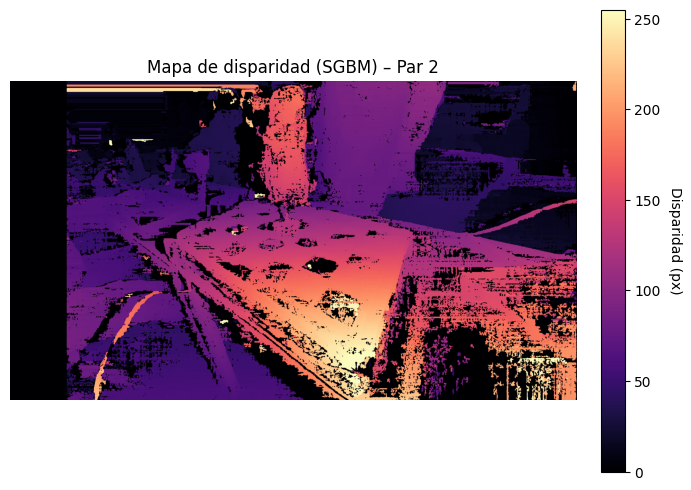

SGBM – Par 3 → min: -16.0, max: 3056.0


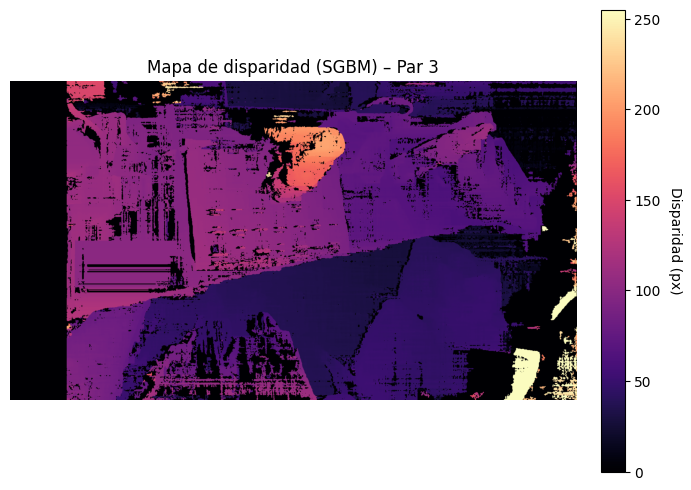

In [9]:
importlib.reload(auxiliares)

for idx, (left_path, right_path) in zip(pares_indices, pares_imgs):
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(
        imgL, imgR,
        build_matcher_fn=auxiliares.make_sgbm,
        min_disp=0,
        num_disp=16*12,
        block=5,
        P1=8 * 3 * 5**2,
        P2=32 * 3 * 5**2,
        disp12MaxDiff=1,
        uniquenessRatio=8,
        speckleWindowSize=100,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    print(f"SGBM – Par {idx+1} → min: {disp_raw.min():.1f}, max: {disp_raw.max():.1f}")

    plt.figure(figsize=(8,6))
    im = plt.imshow(disp_vis, cmap="magma")
    plt.title(f"Mapa de disparidad (SGBM) – Par {idx+1}")
    plt.axis("off")
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Disparidad (px)", rotation=270, labelpad=15)
    plt.show()

### Comparación BM y SGBM

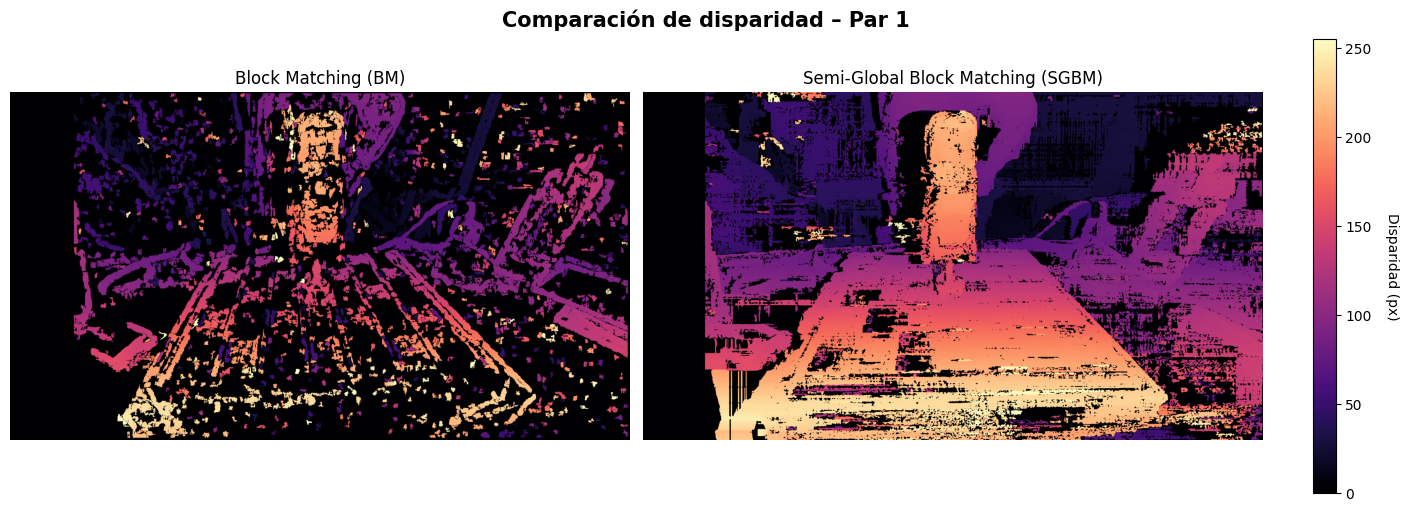

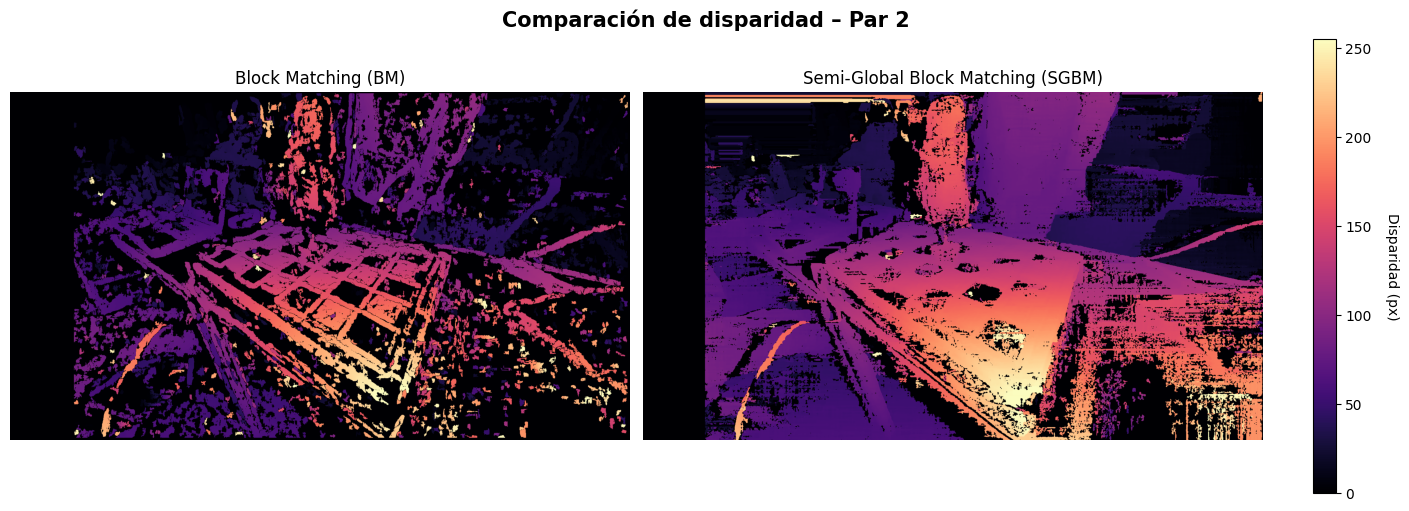

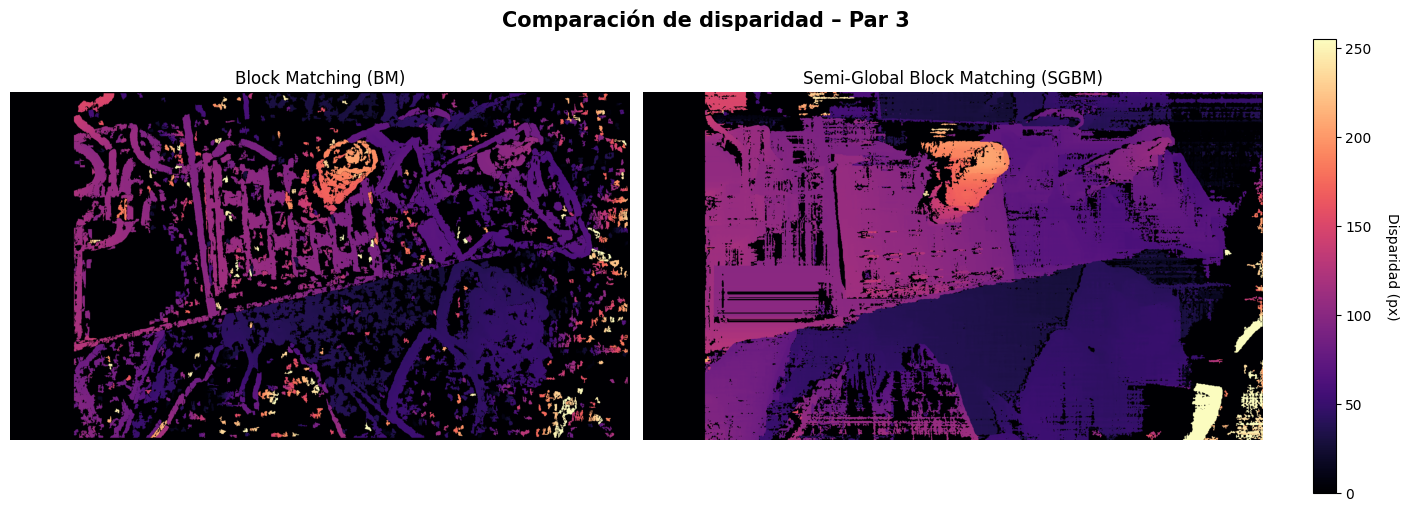

In [10]:
importlib.reload(auxiliares)

for idx, (left_path, right_path) in zip(pares_indices, pares_imgs):
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    # --- BM ---
    disp_bm_raw, disp_bm_vis = auxiliares.calcular_mapa_disparidad(
        imgL, imgR,
        build_matcher_fn=auxiliares.make_bm,
        num_disp=16*12,
        block=15,
        textureThreshold=10,
        uniquenessRatio=5,
        speckleRange=32,
        speckleWindowSize=100
    )

    # --- SGBM ---
    disp_sgbm_raw, disp_sgbm_vis = auxiliares.calcular_mapa_disparidad(
        imgL, imgR,
        build_matcher_fn=auxiliares.make_sgbm,
        min_disp=0,
        num_disp=16*12,
        block=5,
        P1=8 * 3 * 5**2,
        P2=32 * 3 * 5**2,
        disp12MaxDiff=1,
        uniquenessRatio=8,
        speckleWindowSize=100,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    # --- Figura comparativa ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    fig.suptitle(f"Comparación de disparidad – Par {idx+1}", fontsize=15, weight='bold')

    # Escala compartida para comparación justa
    vmin = min(disp_bm_vis.min(), disp_sgbm_vis.min())
    vmax = max(disp_bm_vis.max(), disp_sgbm_vis.max())

    im1 = axes[0].imshow(disp_bm_vis, cmap="magma", vmin=vmin, vmax=vmax)
    axes[0].set_title("Block Matching (BM)", fontsize=12)
    axes[0].axis("off")

    im2 = axes[1].imshow(disp_sgbm_vis, cmap="magma", vmin=vmin, vmax=vmax)
    axes[1].set_title("Semi-Global Block Matching (SGBM)", fontsize=12)
    axes[1].axis("off")

    cbar = fig.colorbar(im2, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
    cbar.set_label("Disparidad (px)", rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=10)

    plt.show()

### Búsqueda de Hiperparámetros 

#### BM

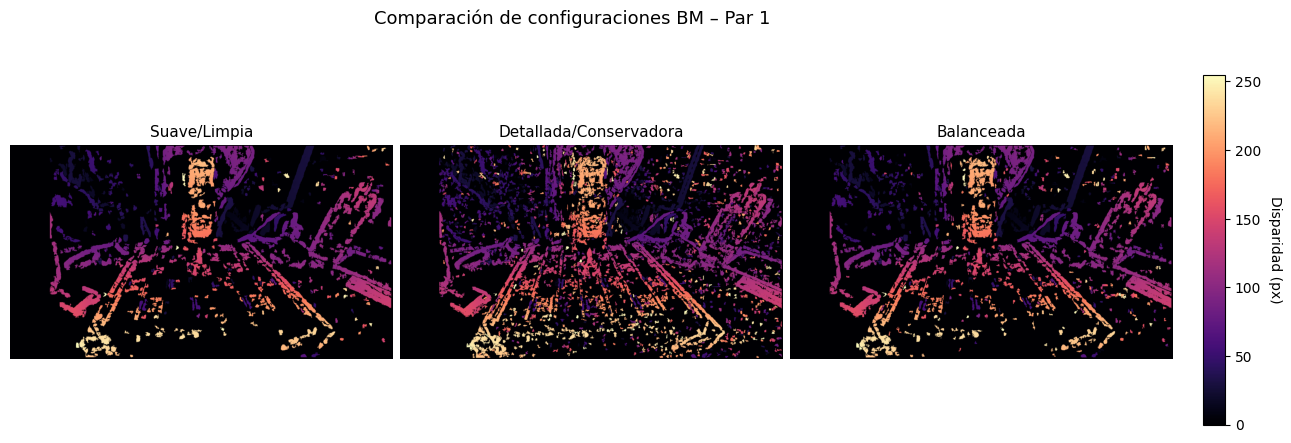

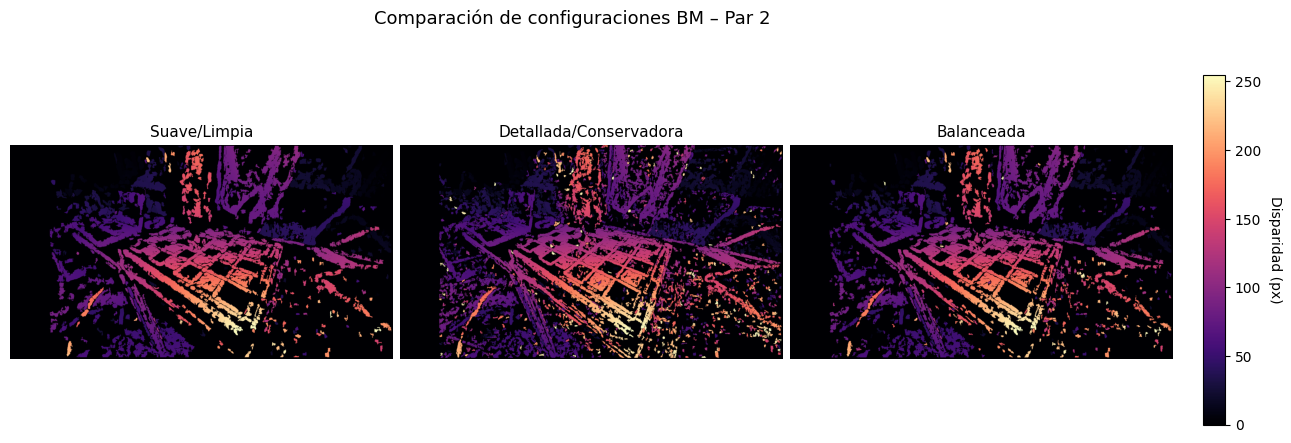

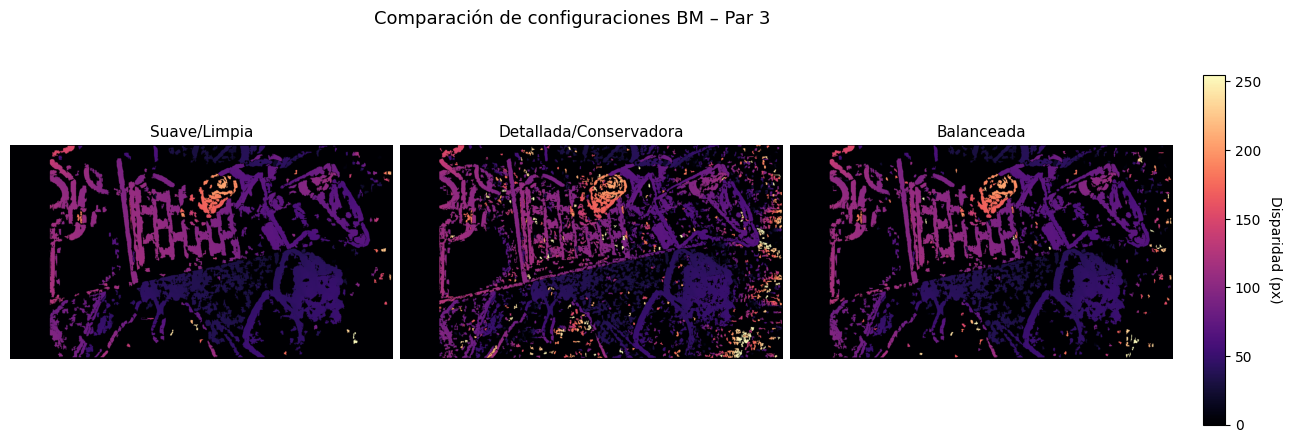

In [11]:
importlib.reload(auxiliares)

# =============================================================================
# Parámetros por defecto para StereoBM (Baseline)
# -----------------------------------------------------------------------------
# num_disp         = 16 * 12
# block            = 15   
# preFilterType    = XSOBEL 
# preFilterSize    = 9      
# preFilterCap     = 31# 
# textureThreshold = 10         
# uniquenessRatio  = 5          
# speckleRange     = 32         
# speckleWindowSize= 100        
# =============================================================================

configs = [
    dict(name="Suave/Limpia", block=19, textureThreshold=5, uniquenessRatio=10,
         speckleRange=16, speckleWindowSize=150),
    dict(name="Detallada/Conservadora", block=13, textureThreshold=8, uniquenessRatio=5,
         speckleRange=32, speckleWindowSize=80),
    dict(name="Balanceada", block=17, textureThreshold=5, uniquenessRatio=10,
         speckleRange=16, speckleWindowSize=100)
]

def build_bm_from_cfg(cfg):
    return auxiliares.make_bm(num_disp=16*12,
                   block=cfg["block"],
                   textureThreshold=cfg["textureThreshold"],
                   uniquenessRatio=cfg["uniquenessRatio"],
                   speckleRange=cfg["speckleRange"],
                   speckleWindowSize=cfg["speckleWindowSize"])

for i, (left_path, right_path) in enumerate(pares_imgs, start=1):
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Comparación de configuraciones BM – Par {i}", fontsize=13)

    for ax, cfg in zip(axs, configs):
        stereo = lambda **_: build_bm_from_cfg(cfg)
        disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, stereo, **cfg)
        im = ax.imshow(disp_vis, cmap="magma")
        ax.set_title(cfg["name"], fontsize=11)
        ax.axis("off")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    fig.colorbar(im, cax=cbar_ax).set_label("Disparidad (px)", rotation=270, labelpad=15)

    plt.subplots_adjust(right=0.9, wspace=0.02)
    plt.show()

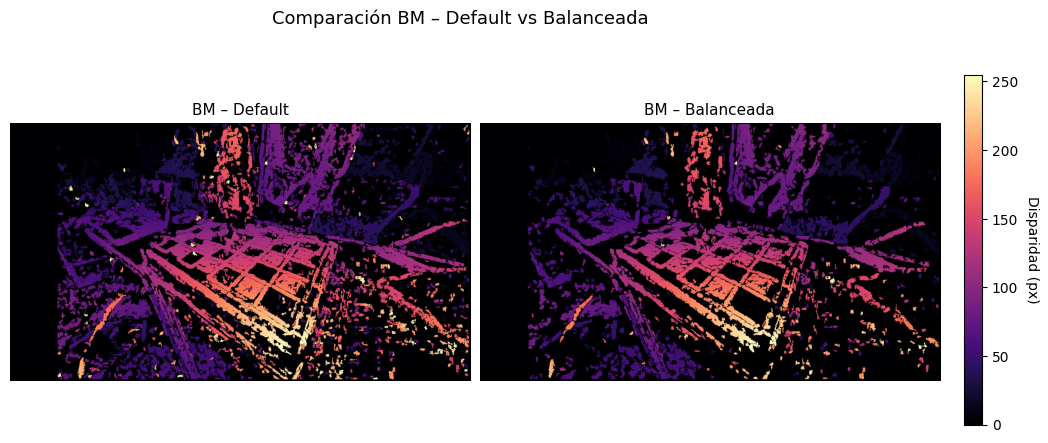

In [12]:
importlib.reload(auxiliares)

# Cargar la segunda pareja de imágenes
left_path, right_path = pares_imgs[1]
imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

# 1. BM: default vs balanceada

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Comparación BM – Default vs Balanceada", fontsize=13)

# --- Default ---
stereo_bm_default = auxiliares.make_bm(num_disp=16*12, block=15, textureThreshold=10,
                            uniquenessRatio=5, speckleRange=32, speckleWindowSize=100)
disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, lambda **_: stereo_bm_default)
im = axs[0].imshow(disp_vis, cmap="magma")
axs[0].set_title("BM – Default", fontsize=11)
axs[0].axis("off")

# --- Balanceada ---
stereo_bm_bal = auxiliares.make_bm(num_disp=16*12, block=17, textureThreshold=5,
                        uniquenessRatio=10, speckleRange=16, speckleWindowSize=100)
disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, lambda **_: stereo_bm_bal)
im = axs[1].imshow(disp_vis, cmap="magma")
axs[1].set_title("BM – Balanceada", fontsize=11)
axs[1].axis("off")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label("Disparidad (px)", rotation=270, labelpad=15)
plt.subplots_adjust(right=0.9, wspace=0.02)
plt.show()

#### SGBM

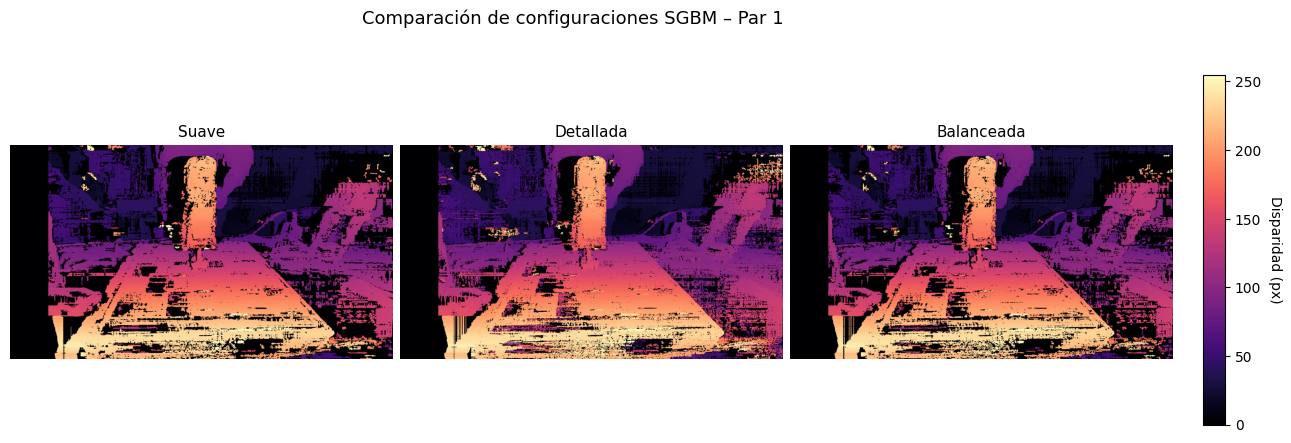

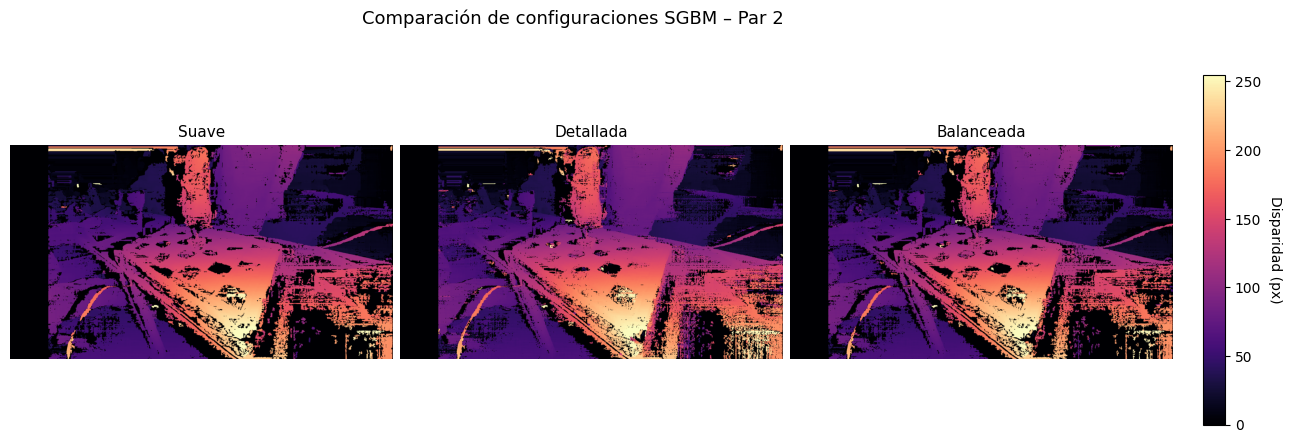

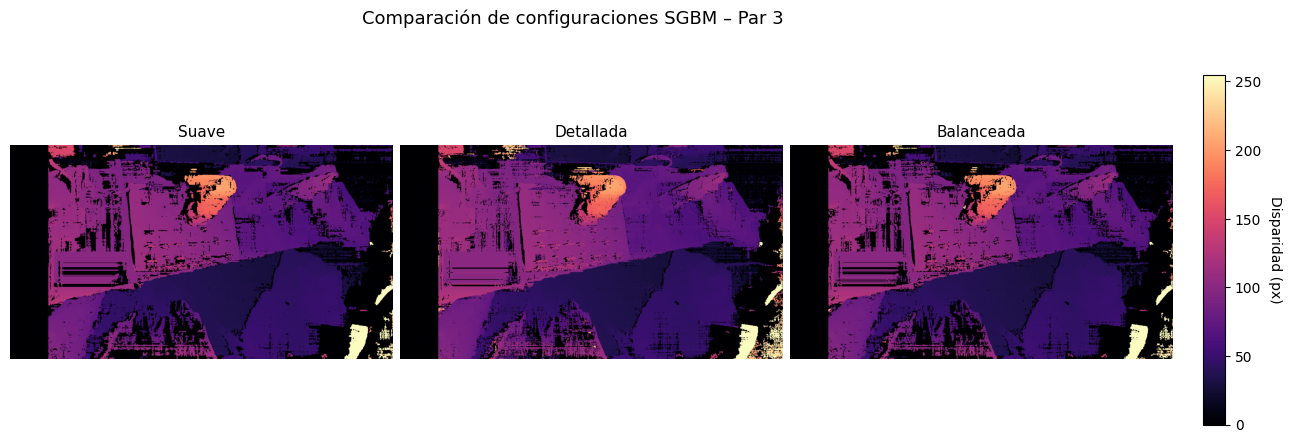

In [13]:
importlib.reload(auxiliares)

# =============================================================================
# Parámetros por defecto para StereoSGBM (Baseline)
# -----------------------------------------------------------------------------
# min_disp          = 0
# num_disp          = 16 * 12
# block             = 5
# P1                = 8 * 3 * block**2 
# P2                = 32 * 3 * block**2  
# disp12MaxDiff     = 1                    
# uniquenessRatio   = 10                   
# speckleWindowSize = 100
# speckleRange      = 32
# preFilterCap      = 63
# mode              = cv2.STEREO_SGBM_MODE_SGBM_3WAY
# =============================================================================

configs = [
    dict(name="Suave", block=7, P1=8*3*7**2, P2=32*3*7**2,
         uniquenessRatio=10, speckleRange=16, speckleWindowSize=150),
    dict(name="Detallada", block=3, P1=8*3*3**2, P2=32*3*3**2,
         uniquenessRatio=5, speckleRange=32, speckleWindowSize=80),
    dict(name="Balanceada", block=5, P1=8*3*5**2, P2=32*3*5**2,
         uniquenessRatio=10, speckleRange=16, speckleWindowSize=100)
]

def build_sgbm_from_cfg(cfg):
    return auxiliares.make_sgbm(
        min_disp=0,
        num_disp=16*12,
        block=cfg["block"],
        P1=cfg["P1"],
        P2=cfg["P2"],
        uniquenessRatio=cfg["uniquenessRatio"],
        speckleRange=cfg["speckleRange"],
        speckleWindowSize=cfg["speckleWindowSize"]
    )

for i, (left_path, right_path) in enumerate(pares_imgs, start=1):
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Comparación de configuraciones SGBM – Par {i}", fontsize=13)

    for ax, cfg in zip(axs, configs):
        stereo = lambda **_: build_sgbm_from_cfg(cfg)
        disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, stereo, **cfg)
        im = ax.imshow(disp_vis, cmap="magma")
        ax.set_title(cfg["name"], fontsize=11)
        ax.axis("off")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax).set_label("Disparidad (px)", rotation=270, labelpad=15)

    plt.subplots_adjust(right=0.9, wspace=0.02)
    plt.show()

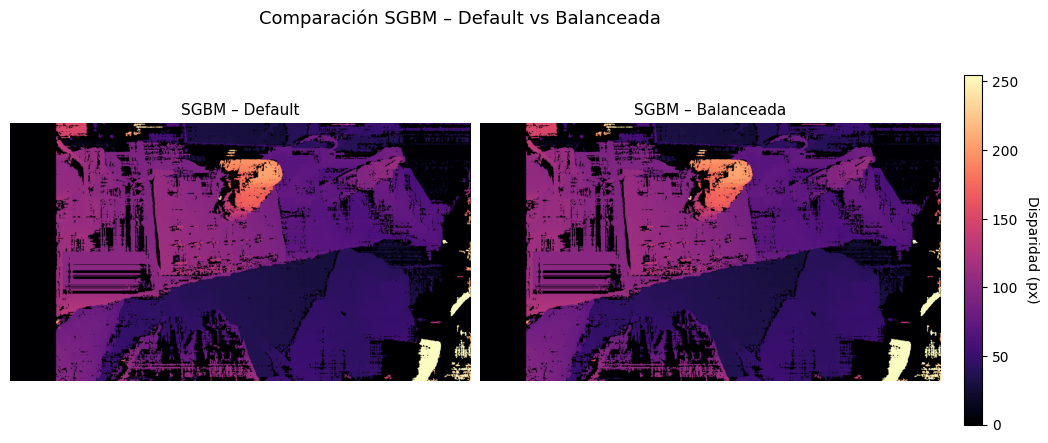

In [14]:
importlib.reload(auxiliares)

# 2. SGBM: default vs balanceada

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Comparación SGBM – Default vs Balanceada", fontsize=13)

# --- Default ---
stereo_sgbm_default = auxiliares.make_sgbm(num_disp=16*12, block=5, uniquenessRatio=10,
                                speckleRange=32, speckleWindowSize=100)
disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, lambda **_: stereo_sgbm_default)
im = axs[0].imshow(disp_vis, cmap="magma")
axs[0].set_title("SGBM – Default", fontsize=11)
axs[0].axis("off")

# --- Balanceada ---
stereo_sgbm_bal = auxiliares.make_sgbm(num_disp=16*12, block=5, uniquenessRatio=10,
                            speckleRange=16, speckleWindowSize=100)
disp_raw, disp_vis = auxiliares.calcular_mapa_disparidad(imgL, imgR, lambda **_: stereo_sgbm_bal)
im = axs[1].imshow(disp_vis, cmap="magma")
axs[1].set_title("SGBM – Balanceada", fontsize=11)
axs[1].axis("off")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label("Disparidad (px)", rotation=270, labelpad=15)
plt.subplots_adjust(right=0.9, wspace=0.02)
plt.show()

### Stereodemo

In [15]:
importlib.reload(auxiliares)

# Ruta base del modelo CREStereo
models_path = Path.home() / ".cache" / "stereodemo" / "models"

models_dir = Path.home() / ".cache" / "stereodemo" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# === Ejemplo de uso ===
auxiliares.procesar_imagenes_rectificadas(
    path_imgs="imgs/objeto/rectificadas",
    out_dir="imgs/objeto",
    metodo="cre"            # "cre", "bm" o "sgbm"
)

🔹 Encontradas 21 imágenes izquierdas
🔹 Encontradas 21 imágenes derechas

➡️  Procesando par 1/21: rect_left_0.jpg
   ✅ Guardado: disp_color_0.png
➡️  Procesando par 2/21: rect_left_1.jpg
   ✅ Guardado: disp_color_1.png
➡️  Procesando par 3/21: rect_left_10.jpg
   ✅ Guardado: disp_color_10.png
➡️  Procesando par 4/21: rect_left_11.jpg
   ✅ Guardado: disp_color_11.png
➡️  Procesando par 5/21: rect_left_12.jpg
   ✅ Guardado: disp_color_12.png
➡️  Procesando par 6/21: rect_left_13.jpg
   ✅ Guardado: disp_color_13.png
➡️  Procesando par 7/21: rect_left_14.jpg
   ✅ Guardado: disp_color_14.png
➡️  Procesando par 8/21: rect_left_15.jpg
   ✅ Guardado: disp_color_15.png
➡️  Procesando par 9/21: rect_left_16.jpg
   ✅ Guardado: disp_color_16.png
➡️  Procesando par 10/21: rect_left_17.jpg
   ✅ Guardado: disp_color_17.png
➡️  Procesando par 11/21: rect_left_18.jpg
   ✅ Guardado: disp_color_18.png
➡️  Procesando par 12/21: rect_left_19.jpg
   ✅ Guardado: disp_color_19.png
➡️  Procesando par 13/21: re

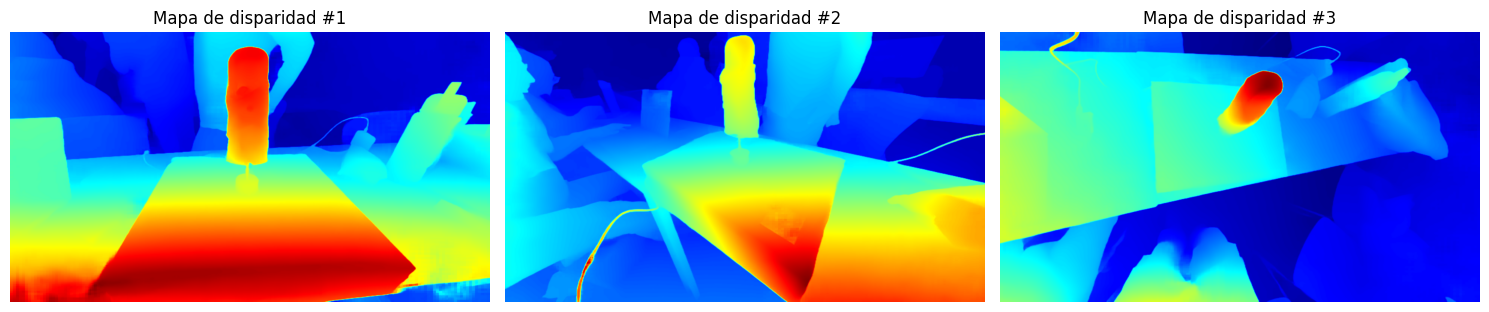

In [16]:
# Carpeta con las imágenes visuales
path_visual = "imgs/objeto/disparidad_cre"  # o "imgs/objeto/disparidad/visual"

# Buscar mapas
disp_imgs = sorted(glob.glob(os.path.join(path_visual, "disp_color_*.png")))

# Mostrar algunos ejemplos
n = 3
fig, axes = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    disp = cv2.imread(disp_imgs[i])
    disp_rgb = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    axes[i].imshow(disp_rgb)
    axes[i].set_title(f"Mapa de disparidad #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# Profundidad y transformacion de puntos 3D

In [ ]:
# =========================================================
# VERSIÓN FINAL OPTIMIZADA - BBOX CORRECTO + MÁS DETALLE
# =========================================================

import cv2
import numpy as np
import open3d as o3d
import pickle
import os
import glob

# =========================================================
# CONFIGURACIÓN
# =========================================================
DICTIONARY_TYPE = cv2.aruco.DICT_6X6_250
SQUARES_X = 5
SQUARES_Y = 7
SQUARE_LENGTH = 52.6
MARKER_LENGTH = 31.3

aruco_dict = cv2.aruco.getPredefinedDictionary(DICTIONARY_TYPE)
charuco_board = cv2.aruco.CharucoBoard(
    (SQUARES_X, SQUARES_Y),
    SQUARE_LENGTH / 1000.0,
    MARKER_LENGTH / 1000.0,
    aruco_dict
)

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def detect_charuco_markers(image, board, detector_params=None):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image

    if not detector_params:
        detector_params = cv2.aruco.DetectorParameters()
        detector_params.adaptiveThreshWinSizeMin = 3
        detector_params.adaptiveThreshWinSizeMax = 23
        detector_params.adaptiveThreshWinSizeStep = 10
        detector_params.minMarkerPerimeterRate = 0.03
        detector_params.maxMarkerPerimeterRate = 4.0

    detector = cv2.aruco.ArucoDetector(board.getDictionary(), detector_params)
    corners, ids, rejected = detector.detectMarkers(gray)

    if ids is None or len(ids) == 0:
        return None

    ids = ids.flatten()
    order = np.argsort(ids)
    ids = ids[order]
    corners = [corners[i] for i in order]

    return {'corners': corners, 'ids': ids, 'rejected': rejected}


def estimate_camera_pose_with_homography(image, board, detection, calibration, undistort=False):
    corners = detection['corners']
    ids = detection['ids']
    K, dist = calibration

    if len(ids) < 4:
        return None

    image_points = []
    board_points = []

    board_ids = board.getIds()
    points3d = board.getObjPoints()
    
    for corner, id in zip(corners, ids):
        id = int(id)
        if id not in board_ids:
            continue
        point3d = points3d[id]
        image_points.extend(corner[0])
        board_points.extend(point3d)

    image_points = np.array(image_points, dtype=np.float32)
    board_points = np.array(board_points, dtype=np.float32)

    if len(image_points) < 4:
        return None

    if undistort:
        use_image_points = cv2.undistortPoints(
            image_points.reshape(-1, 1, 2), K, dist, P=K
        ).reshape(-1, 2)
    else:
        use_image_points = image_points

    H, inliers = cv2.findHomography(board_points[:, :2], use_image_points, method=cv2.LMEDS)

    if H is None:
        return None

    charuco_obj_points = []
    chess = board.getChessboardCorners()
    for i in range(chess.shape[0]):
        charuco_obj_points.append(chess[i])

    charuco_board_points = np.array(
        [p[:2] for p in charuco_obj_points], dtype=np.float32
    ).reshape(-1, 1, 2)

    projected_charuco_corners = cv2.perspectiveTransform(charuco_board_points, H)
    projected_charuco_corners = projected_charuco_corners.reshape(-1, 2)

    obj_pts = np.array(charuco_obj_points, dtype=np.float32)

    if undistort:
        use_image_points = cv2.undistortPoints(
            projected_charuco_corners.reshape(-1, 1, 2), K, dist, P=K
        ).reshape(-1, 2)
    else:
        use_image_points = projected_charuco_corners

    success, rvec, tvec = cv2.solvePnP(
        obj_pts, use_image_points, K, dist, flags=cv2.SOLVEPNP_IPPE
    )

    if not success:
        return None

    return success, rvec, tvec


def detect_charuco_pose(image, camera_matrix, dist_coeffs, board, verbose=False):
    detection = detect_charuco_markers(image, board)
    
    if detection is None:
        if verbose:
            print("  ❌")
        return False, None, None, None, None
    
    if verbose:
        print(f"  ✅ {len(detection['ids'])}m", end="")
    
    result = estimate_camera_pose_with_homography(
        image, board, detection, (camera_matrix, dist_coeffs), undistort=False
    )
    
    if result is None:
        if verbose:
            print(" ❌")
        return False, None, None, None, None
    
    success, rvec, tvec = result
    tvec_mm = tvec * 1000.0
    
    return success, rvec, tvec_mm, detection['corners'], detection['ids']


def create_transform_matrix(rvec, tvec):
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[0:3, 0:3] = R
    T[0:3, 3] = tvec.flatten()
    return T


def filtrar_puntos_3d_mejorado(points_3d, disparity, max_distance_mm=1500.0, min_disparity=10.0):
    mask = np.ones(disparity.shape, dtype=bool)
    
    mask &= (disparity > min_disparity)
    mask &= np.isfinite(points_3d[:, :, 0])
    mask &= np.isfinite(points_3d[:, :, 1])
    mask &= np.isfinite(points_3d[:, :, 2])
    
    distances = np.linalg.norm(points_3d, axis=2)
    mask &= (distances < max_distance_mm) & (distances > 150.0)
    
    mask &= (points_3d[:, :, 2] > 0) & (points_3d[:, :, 2] < max_distance_mm)
    mask &= (np.abs(points_3d[:, :, 0]) < max_distance_mm * 0.8)
    mask &= (np.abs(points_3d[:, :, 1]) < max_distance_mm * 0.8)
    
    return mask


def convertir_a_escala_grises(point_cloud):
    if not point_cloud.has_colors():
        point_cloud.paint_uniform_color([0.5, 0.5, 0.5])
        return point_cloud
    
    colors = np.asarray(point_cloud.colors)
    gray_values = 0.299 * colors[:, 0] + 0.587 * colors[:, 1] + 0.114 * colors[:, 2]
    gray_colors = np.column_stack([gray_values, gray_values, gray_values])
    point_cloud.colors = o3d.utility.Vector3dVector(gray_colors)
    
    return point_cloud


def crear_bounding_box_manual(points, z_min_manual, z_max_manual, 
                                percentile_xy=85, scale_xy=1.0):
    """
    ✅ BBOX CON RANGO Z MANUAL AJUSTADO
    
    Args:
        percentile_xy: 85 (más restrictivo para X/Y)
        scale_xy: 1.0 (sin margen extra)
    """
    min_p = 100 - percentile_xy
    max_p = percentile_xy
    
    x_min = np.percentile(points[:, 0], min_p)
    x_max = np.percentile(points[:, 0], max_p)
    y_min = np.percentile(points[:, 1], min_p)
    y_max = np.percentile(points[:, 1], max_p)
    
    z_min = z_min_manual
    z_max = z_max_manual
    
    centro = np.array([
        (x_min + x_max) / 2,
        (y_min + y_max) / 2,
        (z_min + z_max) / 2
    ])
    
    width_x = (x_max - x_min) * scale_xy
    width_y = (y_max - y_min) * scale_xy
    width_z = z_max - z_min
    
    extent = [width_x / 2, width_y / 2, width_z / 2]
    
    print(f"\n🔲 BBOX CONFIGURADO:")
    print(f"   Centro: [{centro[0]:.1f}, {centro[1]:.1f}, {centro[2]:.1f}] mm")
    print(f"   Extent: [{extent[0]:.1f}, {extent[1]:.1f}, {extent[2]:.1f}] mm")
    print(f"   Rango X: [{x_min:.1f}, {x_max:.1f}] (P{min_p}-P{max_p})")
    print(f"   Rango Y: [{y_min:.1f}, {y_max:.1f}] (P{min_p}-P{max_p})")
    print(f"   Rango Z: [{z_min:.1f}, {z_max:.1f}] (manual)")
    
    return centro, extent


def crear_bounding_box_filtro(center, extent):
    bbox = o3d.geometry.OrientedBoundingBox(center, np.eye(3), extent)
    bbox.color = [1.0, 0.0, 0.0]
    return bbox


def filtrar_por_bounding_box(point_cloud, center, extent):
    bbox = crear_bounding_box_filtro(center, extent)
    idx = bbox.get_point_indices_within_bounding_box(point_cloud.points)
    idx = np.asarray(idx, dtype=np.int64)

    filtered_pc = o3d.geometry.PointCloud()
    pts = np.asarray(point_cloud.points)
    
    if idx.size == 0:
        print("⚠️ Bbox vacío - Ajusta Z_MIN y Z_MAX")
        return filtered_pc, bbox

    filtered_pts = pts[idx]
    filtered_pc.points = o3d.utility.Vector3dVector(filtered_pts)

    if point_cloud.has_colors():
        cols = np.asarray(point_cloud.colors)
        if cols.shape[0] == pts.shape[0]:
            filtered_cols = cols[idx]
            filtered_pc.colors = o3d.utility.Vector3dVector(filtered_cols)
        else:
            filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])
    else:
        filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])

    return filtered_pc, bbox


# =========================================================
# RECONSTRUCCIÓN 3D CON MÁS DETALLE
# =========================================================

def reconstruccion_3d_muneca(max_distance_mm=1500.0, voxel_size_mm=1.5, 
                              outlier_nb_neighbors=25, outlier_std_ratio=2.0):
    """
    ✅ PARÁMETROS OPTIMIZADOS PARA DETALLE:
    - voxel_size_mm=1.5 (MÁS DETALLE que 3mm)
    - outlier_std_ratio=2.0 (MENOS agresivo)
    - outlier_nb_neighbors=25 (balance)
    """
    base_dir = "imgs"
    calib_path = os.path.join(base_dir, "calibracion/stereo_calibration.pkl")
    maps_path = os.path.join(base_dir, "calibracion/stereo_maps.pkl")
    
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    with open(maps_path, "rb") as f:
        maps = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    Q = maps["Q"]
    
    objeto_dir = os.path.join(base_dir, "objeto")
    disparity_dir = os.path.join(objeto_dir, "disparidad_cre")
    left_imgs_original = sorted(glob.glob(os.path.join(objeto_dir, "left_*.jpg")))
    
    all_point_clouds = []
    successful_reconstructions = 0
    
    print("🔹 Reconstrucción 3D - MÁS DETALLE")
    print(f"   max={max_distance_mm/1000:.1f}m, voxel={voxel_size_mm}mm, outliers=±{outlier_std_ratio}σ\n")
    
    for i, left_img_path in enumerate(left_imgs_original):
        print(f"[{i+1:2d}/{len(left_imgs_original)}]", end=" ")
        
        left_img_original = cv2.imread(left_img_path)
        if left_img_original is None:
            print("❌")
            continue
        
        success, rvec, tvec_mm, corners, ids = detect_charuco_pose(
            left_img_original, left_K, left_dist, charuco_board, verbose=True
        )
        
        if not success:
            continue
        
        C_T_O = create_transform_matrix(rvec, tvec_mm)
        O_T_C = np.linalg.inv(C_T_O)
        
        R_flip = np.array([[1, 0, 0], [0, -1, 0], [0, 0, 1]])
        T_flip = np.eye(4)
        T_flip[:3, :3] = R_flip
        O_T_C_corrected = T_flip @ O_T_C
        
        base_name = os.path.basename(left_img_path).replace("left_", "").replace(".jpg", "")
        disp_raw_path = os.path.join(disparity_dir, f"disp_raw_{base_name}.npy")
        
        if not os.path.exists(disp_raw_path):
            print(" ❌")
            continue
        
        disparity = np.load(disp_raw_path)
        points_3d = cv2.reprojectImageTo3D(disparity, Q)
        
        mask = filtrar_puntos_3d_mejorado(points_3d, disparity, max_distance_mm, min_disparity=10.0)
        valid_points = points_3d[mask]
        
        if len(valid_points) < 1000:
            print(f" ❌")
            continue
        
        img_left_color = cv2.imread(left_img_path)
        img_left_color = cv2.cvtColor(img_left_color, cv2.COLOR_BGR2RGB)

        if img_left_color.shape[:2] != disparity.shape:
            img_left_color = cv2.resize(img_left_color, 
                                       (disparity.shape[1], disparity.shape[0]), 
                                       interpolation=cv2.INTER_LINEAR)

        colors = img_left_color.reshape(-1, 3) / 255.0
        valid_colors = colors[mask.flatten()]
        
        point_cloud = o3d.geometry.PointCloud()
        point_cloud.points = o3d.utility.Vector3dVector(valid_points)
        point_cloud.colors = o3d.utility.Vector3dVector(valid_colors)
        
        points_camera = np.array(point_cloud.points)
        points_camera_homogeneous = np.column_stack([points_camera, np.ones(len(points_camera))])
        
        points_world_homogeneous = (O_T_C_corrected @ points_camera_homogeneous.T).T
        points_world = points_world_homogeneous[:, :3] / points_world_homogeneous[:, 3:4]
        
        point_cloud.points = o3d.utility.Vector3dVector(points_world)
        
        # Limpieza MENOS agresiva para mantener detalle
        cl, ind = point_cloud.remove_statistical_outlier(
            nb_neighbors=outlier_nb_neighbors, 
            std_ratio=outlier_std_ratio
        )
        point_cloud = point_cloud.select_by_index(ind)
        
        # Downsample con voxel MÁS PEQUEÑO
        point_cloud = point_cloud.voxel_down_sample(voxel_size=voxel_size_mm)
        
        all_point_clouds.append(point_cloud)
        successful_reconstructions += 1
        
        print(f" → {len(point_cloud.points):,}pts")
    
    if len(all_point_clouds) == 0:
        print("\n❌ Sin puntos")
        return None
    
    print(f"\n🔗 Combinando {len(all_point_clouds)} nubes...")
    point_cloud_combined = o3d.geometry.PointCloud()

    all_points = []
    all_colors = []

    for pc in all_point_clouds:
        pts = np.asarray(pc.points)
        all_points.append(pts)

        if pc.has_colors() and len(pc.colors) == len(pc.points):
            all_colors.append(np.asarray(pc.colors))
        else:
            all_colors.append(np.full((pts.shape[0], 3), 0.7, dtype=np.float64))

    combined_points = np.vstack(all_points)
    combined_colors = np.vstack(all_colors)

    point_cloud_combined.points = o3d.utility.Vector3dVector(combined_points)
    point_cloud_combined.colors = o3d.utility.Vector3dVector(combined_colors)

    print(f"   Total: {len(combined_points):,} pts")
    
    # Limpieza global MODERADA
    print(f"🧹 Limpieza global...")
    cl, ind = point_cloud_combined.remove_statistical_outlier(
        nb_neighbors=30, 
        std_ratio=2.0  # Menos agresivo
    )
    point_cloud_combined = point_cloud_combined.select_by_index(ind)
    print(f"   Final: {len(point_cloud_combined.points):,} pts")
    
    print(f"\n{'='*60}")
    print(f"🎉 Éxito: {successful_reconstructions}/{len(left_imgs_original)}")
    print(f"{'='*60}\n")
    
    point_cloud_gray = o3d.geometry.PointCloud(point_cloud_combined)
    point_cloud_gray = convertir_a_escala_grises(point_cloud_gray)
    
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[0, 0, 0])

    print("🔍 Visualizando...")
    o3d.visualization.draw_geometries(
        [point_cloud_gray, coordinate_frame],
        window_name="Reconstrucción 3D Muñeca",
        width=1280,
        height=720,
        point_show_normal=False
    )
    
    output_path = os.path.join(base_dir, "objeto/reconstruccion_3d/reconstruccion_muneca_grises.ply")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    o3d.io.write_point_cloud(output_path, point_cloud_gray, write_ascii=False)
    print(f"💾 Guardado: {output_path}\n")
    
    return point_cloud_gray


# =========================================================
# EJECUTAR
# =========================================================

print("=" * 80)
print("RECONSTRUCCIÓN 3D DE LA MUÑECA")
print("=" * 80 + "\n")

point_cloud_final = reconstruccion_3d_muneca(
    max_distance_mm=1500.0,
    voxel_size_mm=1.5,           # ⬅️ MÁS DETALLE (antes 3mm)
    outlier_nb_neighbors=25,     # ⬅️ Balance
    outlier_std_ratio=1.5        # ⬅️ Menos agresivo (antes 1.5)
)

# =========================================================
# BBOX CON RANGO Z CORRECTO
# =========================================================

if point_cloud_final is not None and len(point_cloud_final.points) > 0:
    print("=" * 80)
    print("FILTRADO POR BOUNDING BOX")
    print("=" * 80)
    
    points = np.asarray(point_cloud_final.points)
    print(f"\n📊 Nube completa: {len(points):,} puntos")
    print(f"   X: [{points[:, 0].min():.1f}, {points[:, 0].max():.1f}]")
    print(f"   Y: [{points[:, 1].min():.1f}, {points[:, 1].max():.1f}]")
    print(f"   Z: [{points[:, 2].min():.1f}, {points[:, 2].max():.1f}]")
    
    # ✅ VALORES AJUSTADOS SEGÚN DIAGNÓSTICO
    # Mayor concentración en Z: [14, 179] mm con 40.9% de puntos
    # Región Z2 con 72.7%: [-96, 454] mm
    
    # O usa el centro de masa
    Z_MIN_MUNECA = 132.6 - 300  # Centro ± offset
    Z_MAX_MUNECA = 132.6 + 300
    
    print(f"\n🎯 Usando rango Z basado en diagnóstico:")
    print(f"   Z_MIN = {Z_MIN_MUNECA} mm")
    print(f"   Z_MAX = {Z_MAX_MUNECA} mm")
    print(f"   (Contiene ~73% de los puntos)")
    
    center, extent = crear_bounding_box_manual(
        points,
        z_min_manual=Z_MIN_MUNECA,
        z_max_manual=Z_MAX_MUNECA,
        percentile_xy=85,  # Más restrictivo para X/Y
        scale_xy=1.0       # Sin margen
    )
    
    filtered_pc, bbox = filtrar_por_bounding_box(point_cloud_final, center, extent)
    
    print(f"\n📦 Resultado del filtrado:")
    print(f"   Puntos antes: {len(points):,}")
    print(f"   Puntos después: {len(filtered_pc.points):,}")
    if len(points) > 0:
        print(f"   Retenidos: {100 * len(filtered_pc.points) / len(points):.1f}%")
    
    if len(filtered_pc.points) == 0:
        print("\n⚠️ BBOX VACÍO - Prueba ajustar:")
        print("   Z_MIN_MUNECA = -200.0")
        print("   Z_MAX_MUNECA = 500.0")
    else:
        coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[0, 0, 0])

        print("\n🔍 Visualizando con bbox...")
        o3d.visualization.draw_geometries(
            [filtered_pc, bbox, coordinate_frame],
            window_name="Muñeca filtrada",
            width=1280,
            height=720,
            point_show_normal=False
        )

        output_filtered = "imgs/objeto/reconstruccion_3d/reconstruccion_muneca_filtrada_grises.ply"
        os.makedirs(os.path.dirname(output_filtered), exist_ok=True)
        o3d.io.write_point_cloud(output_filtered, filtered_pc, write_ascii=False)
        print(f"\n💾 Guardado: {output_filtered}")

print("\n✅ COMPLETADO")

RECONSTRUCCIÓN 3D DE LA MUÑECA

🔹 Reconstrucción 3D - MÁS DETALLE
   max=1.5m, voxel=1.0mm, outliers=±2.0σ

[ 1/21]   ✅ 15m → 889,585pts
[ 2/21]   ✅ 13m → 931,668pts
[ 3/21]   ✅ 13m → 997,380pts
[ 4/21]   ✅ 12m → 1,221,716pts
[ 5/21]   ✅ 13m → 978,202pts
[ 6/21]   ✅ 15m → 840,285pts
[ 7/21]   ✅ 16m → 680,104pts
[ 8/21]   ✅ 12m → 830,443pts
[ 9/21]   ✅ 11m → 584,511pts
[10/21]   ✅ 11m → 726,808pts
[11/21]   ✅ 14m → 816,242pts
[12/21]   ✅ 13m → 859,950pts
[13/21]   ✅ 15m → 649,198pts
[14/21]   ✅ 14m → 896,303pts
[15/21]   ✅ 12m → 787,309pts
[16/21]   ✅ 13m → 819,643pts
[17/21]   ✅ 11m → 776,251pts
[18/21]   ✅ 10m → 665,134pts
[19/21]   ✅ 5m → 680,220pts
[20/21]   ✅ 13m → 662,210pts
[21/21]   ✅ 12m → 545,982pts

🔗 Combinando 21 nubes...
   Total: 16,839,144 pts
🧹 Limpieza global...
   Final: 16,141,447 pts

🎉 Éxito: 21/21

🔍 Visualizando...
💾 Guardado: imgs\objeto/reconstruccion_3d/reconstruccion_muneca_grises.ply

FILTRADO POR BOUNDING BOX

📊 Nube completa: 16,141,447 puntos
   X: [-1078